#1. Loading the dataset

In [6]:
import pandas as pd 

df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

#2. Number of Rows and Columns

In [7]:
print(df.shape)
print(df.columns.tolist())

(5268, 13)
['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Fatalities', 'Ground', 'Summary']


##The dataset has 5268 rows and 13 columns

#3. Display the last 75 rows in the dataset.

In [8]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


#4. Each column except the first one has some missing data. For each column, name
#the most appropriate method for treating the missing data. Justify your choices.

In [9]:
df.isna().sum()

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

##Time - We would label the empty ones as unknown because time is not important for the analysis
##Location - There is no way to know the missing location, so we would just delete those rows
##Operator - For the missing data we would label it as unknown because there is no way to guess the airline name.
##Flight - We think flight number is important in tracking crashes in order to establish an order. We would label the missing ones as Unknown as the .number of flight might be useful somewhere else.
##Route - This is also an important column, we would label the missing ones as Unknown since for the ones that are present, it is important to know the route, maybe one route has more crashes that another.
##Type - We would also label as Unknown for those missing as it is important data.
##Registration - This is the tail number of the aircraft, We would fill it with Unknown
##cn/In - We would delete this whole column as we don't think its important in analysing crashes because it is just the manufaturer serial number
##Aboard - We would fill in with the median number as it gives a better average because the mean will skew the data.
##Fatalities - We will also fill in with the median.
##Ground - We would put 0 becuase in most of the crashes, rarely do people on the ground die
##Summary - We would leave this blank as it just describes the crash, not important information in analyzing

#5. Create a new dataframe from the raw/uncleaned data called
‘fatality_locations’ with the following columns: ‘Date’,
‘Location’, ‘Aboard’, ‘Fatalities’.

In [10]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()


,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


#6. Determine the date of the highest number of recorded fatalities from this new
#dataframe

In [11]:
max_row = fatality_locations.loc[fatality_locations["Fatalities"].idxmax()]
print(max_row)

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object


#7. Compare the number of passengers aboard to the number of fatalities per crash. Are
#there any recorded crashes where there were no fatalities? If so, how many?

In [12]:
comp = fatality_locations.dropna(subset=["Aboard", "Fatalities"])
comp["Survivors"] = comp["Aboard"] - comp["Fatalities"]

zero_fatalities = comp[comp["Fatalities"] == 0]
print(len(zero_fatalities))       
comp[["Aboard", "Fatalities"]].describe()   

58


,Aboard,Fatalities
count,5246.000000,5246.000000
mean,27.554518,20.083492
std,43.076711,33.211457
min,0.000000,0.000000
25%,5.000000,3.000000
50%,13.000000,9.000000
75%,30.000000,23.000000
max,644.000000,583.000000


##There were 58 crashes where there were no fatalities

#8. In the ‘fatality_locations’ dataframe, the location column has data items
#represented as ‘Region, U.S. State/Country’. Split this column to have two columns
#of regions and states/countries.

In [14]:
split_loc = fatality_locations["Location"].str.rsplit(",", n=1, expand=True)
fatality_locations["Region"] = split_loc[0].str.strip()
fatality_locations["State_Country"] = split_loc[1].str.strip()

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,NaN
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


#9. Order the dataframe by the number of fatalities from highest to lowest and select the
#first 100.

In [16]:
top_100 = fatality_locations.sort_values("Fatalities", ascending=False).head(100)
top_100.head(100)

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


#10. Generate a pie chart that shows the distribution of the top 25 number of fatalities
#per country/U.S. State. [Hint: charts can be generated from the seaborn library]

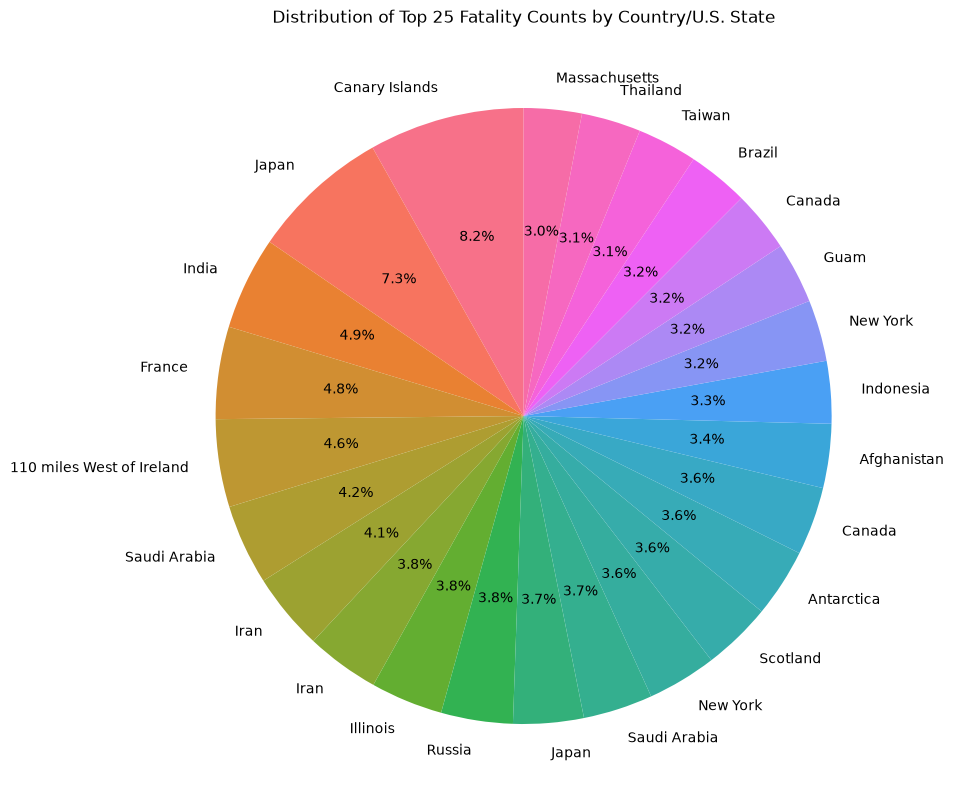

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

top_25 = top_100.sort_values("Fatalities", ascending=False).head(25)

plt.figure(figsize=(10, 10))
colors = sns.color_palette("husl", len(top_25))
plt.pie(
    top_25["Fatalities"],
    labels=top_25["State_Country"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)
plt.title("Distribution of Top 25 Fatality Counts by Country/U.S. State")
plt.show()

# 11. Images for proof of GroupWork

![Group Work Proof 1](groupwork_proof1.png)

![Group Work Proof 2](groupwork_proof2.png)